In [92]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as sk
import scipy as scipy


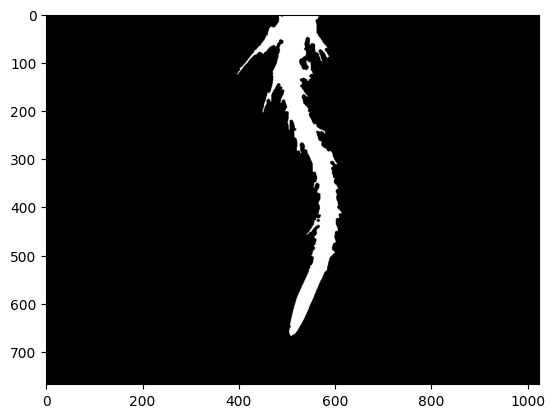

In [93]:
# import image
image_path = '/Users/antoantony/9-30/KO/KO 10 um T0/KO 10 um_1.bmp'
image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# turn it black/white
_, mask = cv2.threshold(image_gray, 110, 255, cv2.THRESH_BINARY_INV)

# 4x4 kernel with adaptive threshold (this actually seems to make it worse, so maybe ignore this part)
# kernel4x4 = np.ones((4,4), np.uint8)
# adapt = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 35, 8)
# # The last two numbers are the block size and the constant subtracted from the mean, respectively. You can adjust these parameters to see how they affect the result.
# adaptive_thresholded = cv2.morphologyEx(adapt, cv2.MORPH_OPEN, kernel4x4)

# connected component
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])  # Skip the background label

CC_mask = np.zeros_like(mask)
CC_mask[labels == largest_label] = 255

# Morphological closing to fill holes
kernel7x7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
closed_mask = cv2.morphologyEx(CC_mask, cv2.MORPH_CLOSE, kernel7x7)

contours, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_closed_contour = np.zeros_like(closed_mask)
cv2.drawContours(mask_closed_contour, contours, -1, 255, -1)

plt.imshow(mask_closed_contour, cmap='gray')
plt.show()

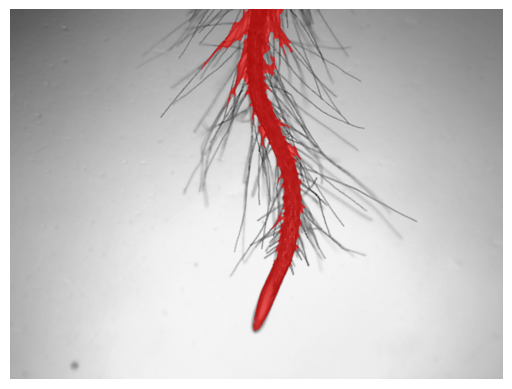

In [94]:
# Create overlay

img_rgb = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)
mask_rgb = cv2.cvtColor(mask_closed_contour, cv2.COLOR_GRAY2RGB)

overlay = img_rgb.copy()
overlay[mask_closed_contour == 255] = [255, 0, 0]  # Red color for the mask area

alpha = 0.4  # Transparency factor
final_overlay = cv2.addWeighted(img_rgb, alpha, overlay, 1 - alpha, 0)

plt.imshow(final_overlay)
plt.axis('off')
plt.show()

Number of connected components: 319


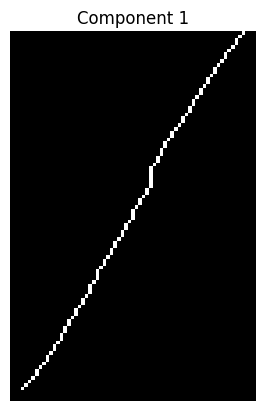

Component 1, length: 125.68 pixels, 
           length: 414.75 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 38,
           diag neighbors: 62"
        


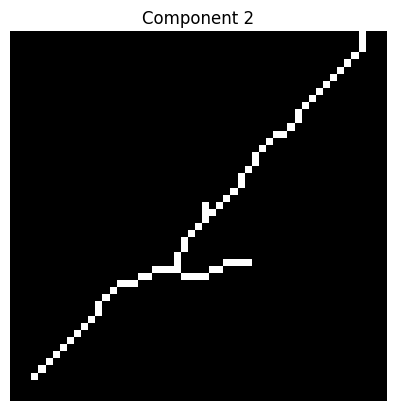

Component 2, length: 88.23 pixels, 
           length: 291.14 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 1, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 26,
           diag neighbors: 44"
        


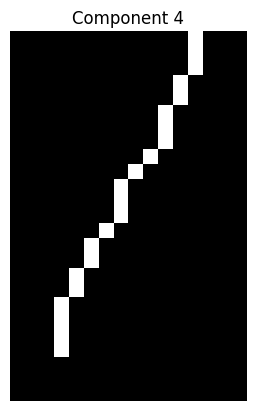

Component 4, length: 24.73 pixels, 
           length: 81.60 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 12,
           diag neighbors: 9"
        


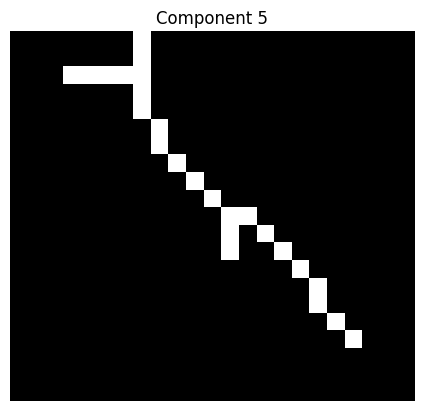

Component 5, length: 32.80 pixels, 
           length: 108.24 microns, 
           endpoints: 0, 
           degrees: [1, 3, 1, 2, 2, 4, 3, 3, 2, 2, 2, 2, 2, 2, 3, 3, 3, 2, 1, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 13,
           diag neighbors: 14"
        


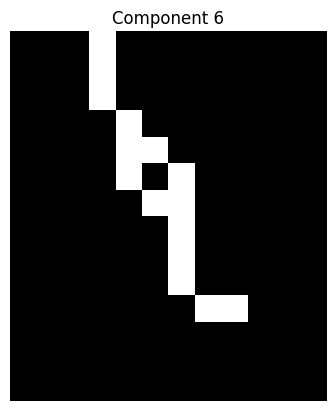

Component 6, length: 22.31 pixels, 
           length: 73.64 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 3, 3, 4, 3, 3, 4, 3, 3, 2, 2, 2, 1],
           ortho neighbors: 11,
           diag neighbors: 8"
        


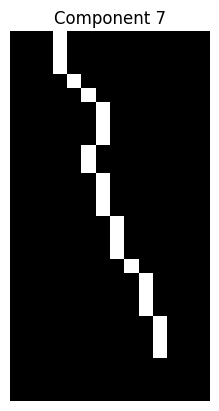

Component 7, length: 25.73 pixels, 
           length: 84.90 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 13,
           diag neighbors: 9"
        


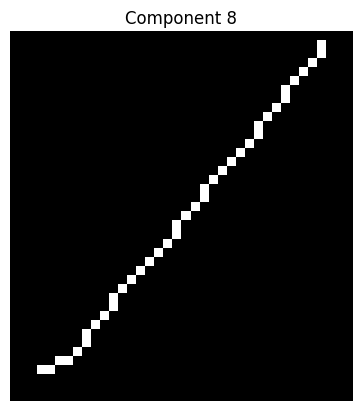

Component 8, length: 50.01 pixels, 
           length: 165.04 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2],
           ortho neighbors: 9,
           diag neighbors: 29"
        


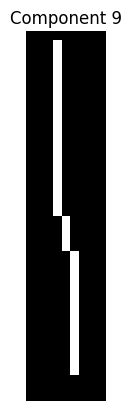

Component 9, length: 37.83 pixels, 
           length: 124.83 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 35,
           diag neighbors: 2"
        


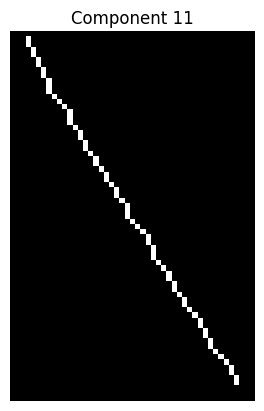

Component 11, length: 82.57 pixels, 
           length: 272.48 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 26,
           diag neighbors: 40"
        


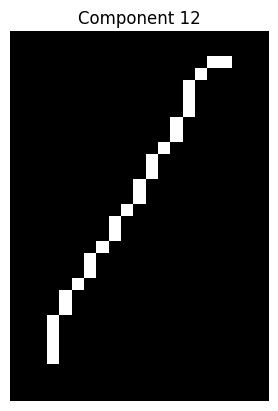

Component 12, length: 30.38 pixels, 
           length: 100.27 microns, 
           endpoints: 0, 
           degrees: [2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 12,
           diag neighbors: 13"
        


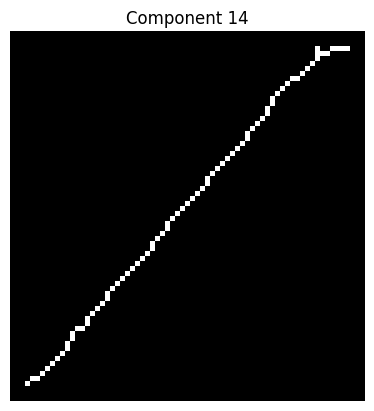

Component 14, length: 102.02 pixels, 
           length: 336.68 microns, 
           endpoints: 0, 
           degrees: [2, 2, 2, 2, 1, 3, 4, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 20,
           diag neighbors: 58"
        


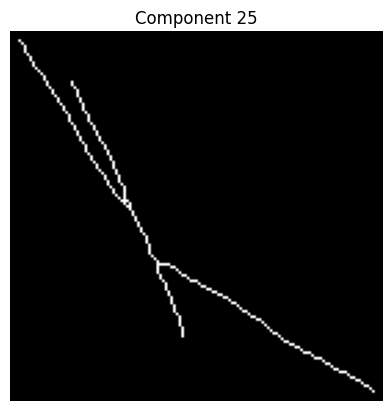

Component 25, length: 295.26 pixels, 
           length: 974.36 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 3, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 4, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 110,
           diag neighbors: 131"
        


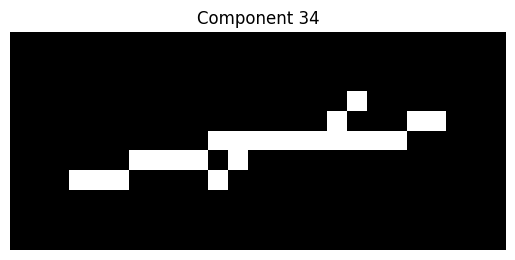

Component 34, length: 31.14 pixels, 
           length: 102.77 microns, 
           endpoints: 0, 
           degrees: [1, 4, 2, 1, 3, 3, 3, 2, 2, 3, 3, 3, 2, 2, 2, 2, 2, 3, 4, 1, 2, 2, 2],
           ortho neighbors: 17,
           diag neighbors: 10"
        


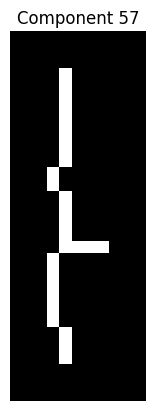

Component 57, length: 29.07 pixels, 
           length: 95.93 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 22,
           diag neighbors: 5"
        


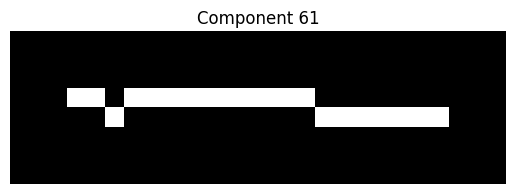

Component 61, length: 20.24 pixels, 
           length: 66.80 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 16,
           diag neighbors: 3"
        


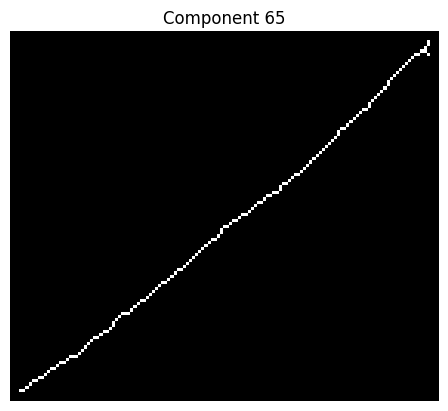

Component 65, length: 186.32 pixels, 
           length: 614.86 microns, 
           endpoints: 0, 
           degrees: [1, 2, 3, 3, 3, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2],
           ortho neighbors: 35,
           diag neighbors: 107"
        


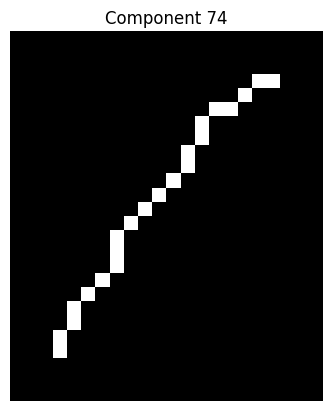

Component 74, length: 26.38 pixels, 
           length: 87.07 microns, 
           endpoints: 0, 
           degrees: [2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 8,
           diag neighbors: 13"
        


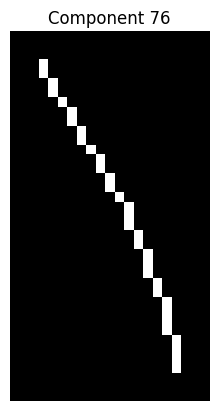

Component 76, length: 37.80 pixels, 
           length: 124.74 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 18,
           diag neighbors: 14"
        


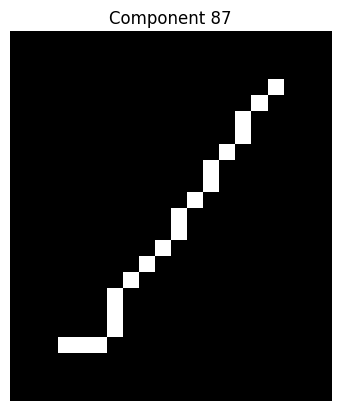

Component 87, length: 22.56 pixels, 
           length: 74.44 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2],
           ortho neighbors: 7,
           diag neighbors: 11"
        


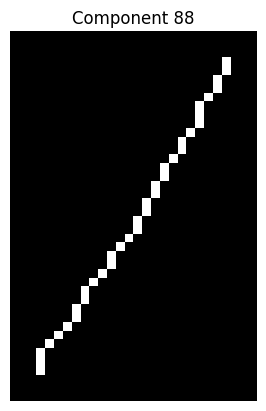

Component 88, length: 43.70 pixels, 
           length: 144.20 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 14,
           diag neighbors: 21"
        


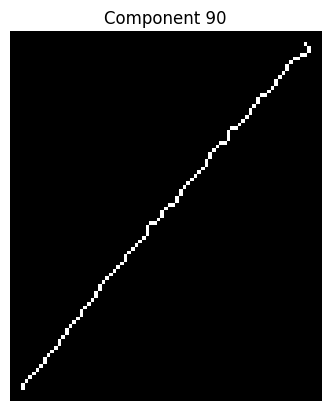

Component 90, length: 130.82 pixels, 
           length: 431.72 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 29,
           diag neighbors: 72"
        


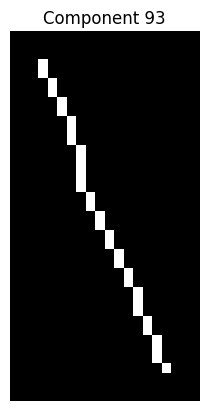

Component 93, length: 37.38 pixels, 
           length: 123.37 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 19,
           diag neighbors: 13"
        


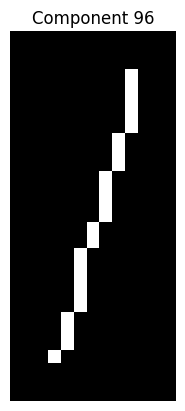

Component 96, length: 24.49 pixels, 
           length: 80.80 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 16,
           diag neighbors: 6"
        


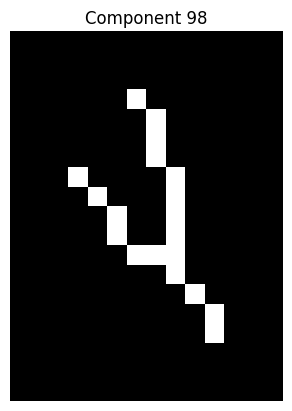

Component 98, length: 23.73 pixels, 
           length: 78.30 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 3, 2, 4, 3, 3, 2, 2, 1],
           ortho neighbors: 11,
           diag neighbors: 9"
        


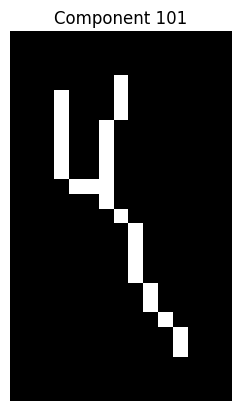

Component 101, length: 31.73 pixels, 
           length: 104.70 microns, 
           endpoints: 0, 
           degrees: [1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 19,
           diag neighbors: 9"
        


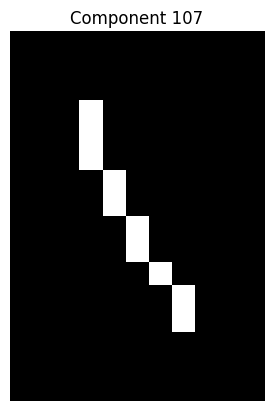

Component 107, length: 10.66 pixels, 
           length: 35.17 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 5,
           diag neighbors: 4"
        


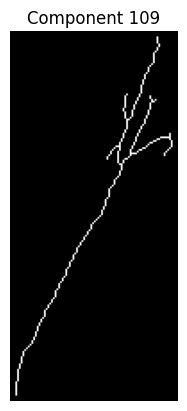

Component 109, length: 364.09 pixels, 
           length: 1201.50 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 3, 1, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 3, 2, 2, 2, 2, 2, 2, 4, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 4, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 4, 2, 2, 2, 2, 2, 3, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2

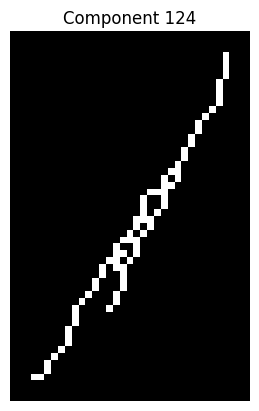

Component 124, length: 121.12 pixels, 
           length: 399.71 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4, 3, 3, 3, 4, 4, 2, 4, 4, 2, 3, 2, 2, 4, 2, 3, 5, 4, 4, 3, 4, 3, 3, 4, 4, 3, 3, 4, 4, 2, 4, 5, 3, 2, 4, 4, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2],
           ortho neighbors: 49,
           diag neighbors: 51"
        


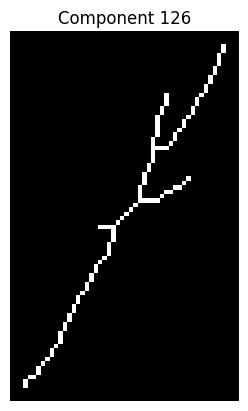

Component 126, length: 132.95 pixels, 
           length: 438.75 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 4, 2, 2, 3, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 58,
           diag neighbors: 53"
        


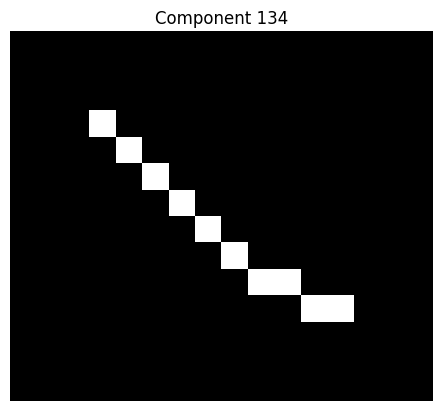

Component 134, length: 11.90 pixels, 
           length: 39.27 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 2,
           diag neighbors: 7"
        


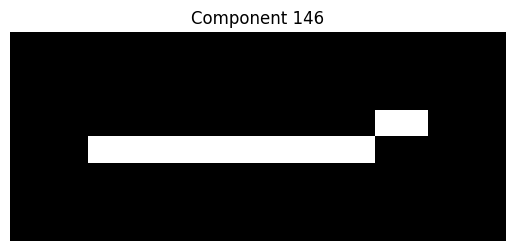

Component 146, length: 12.41 pixels, 
           length: 40.97 microns, 
           endpoints: 0, 
           degrees: [2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
           ortho neighbors: 11,
           diag neighbors: 1"
        


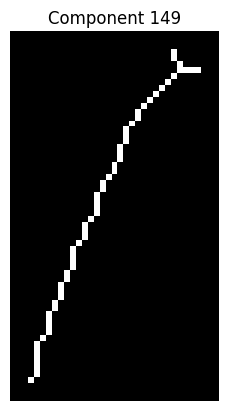

Component 149, length: 70.18 pixels, 
           length: 231.61 microns, 
           endpoints: 0, 
           degrees: [1, 2, 3, 3, 3, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 32,
           diag neighbors: 27"
        


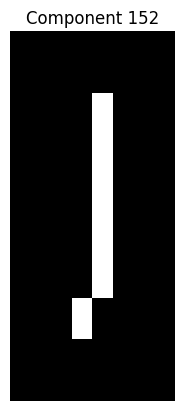

Component 152, length: 11.41 pixels, 
           length: 37.67 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 10,
           diag neighbors: 1"
        


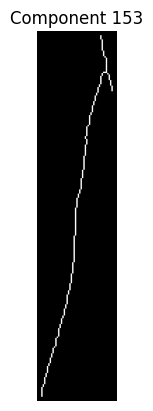

Component 153, length: 295.78 pixels, 
           length: 976.08 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 218,
           diag neighbors

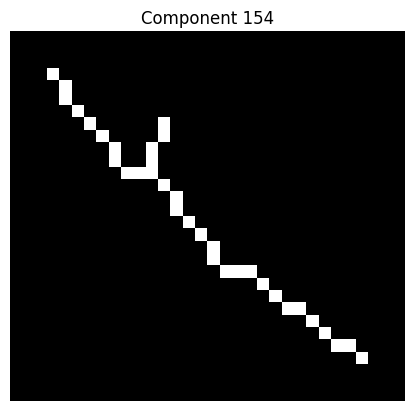

Component 154, length: 42.70 pixels, 
           length: 140.90 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 3, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 13,
           diag neighbors: 21"
        


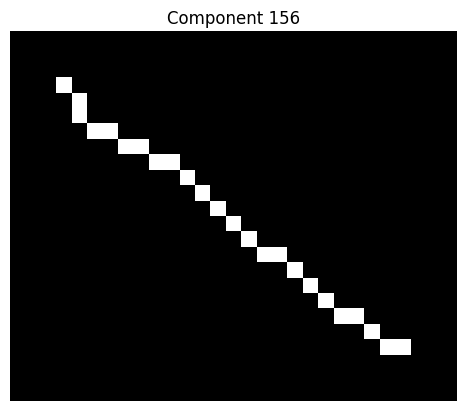

Component 156, length: 29.63 pixels, 
           length: 97.77 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 7,
           diag neighbors: 16"
        


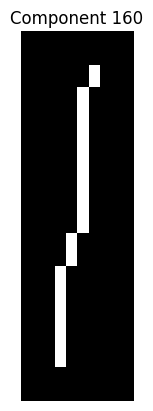

Component 160, length: 27.24 pixels, 
           length: 89.90 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 23,
           diag neighbors: 3"
        


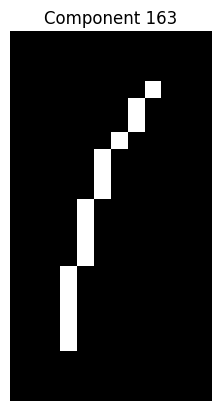

Component 163, length: 17.07 pixels, 
           length: 56.33 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 10,
           diag neighbors: 5"
        


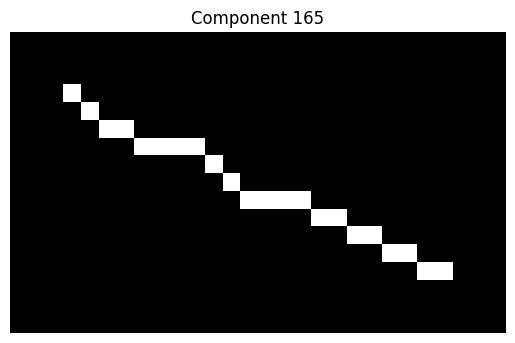

Component 165, length: 25.14 pixels, 
           length: 82.97 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 11,
           diag neighbors: 10"
        


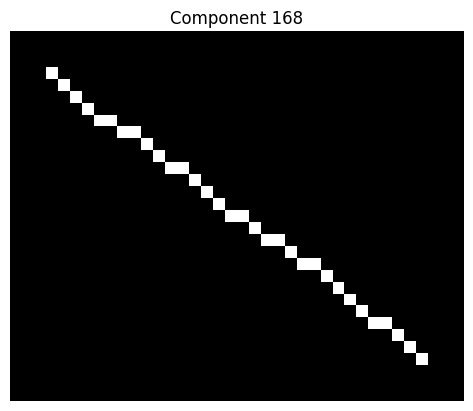

Component 168, length: 40.94 pixels, 
           length: 135.11 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 7,
           diag neighbors: 24"
        


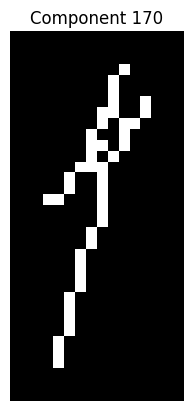

Component 170, length: 60.70 pixels, 
           length: 200.30 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 3, 1, 3, 4, 2, 3, 3, 3, 3, 3, 3, 4, 2, 5, 3, 3, 4, 4, 2, 3, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 31,
           diag neighbors: 21"
        


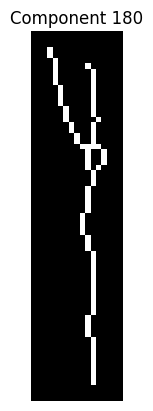

Component 180, length: 98.53 pixels, 
           length: 325.14 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 3, 4, 4, 3, 4, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 66,
           diag neighbors: 23"
        


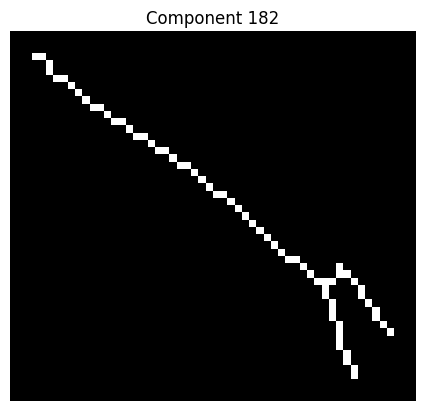

Component 182, length: 87.23 pixels, 
           length: 287.84 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 25,
           diag neighbors: 44"
        


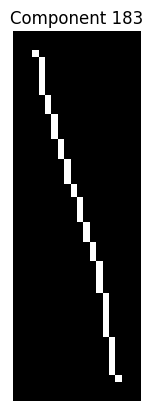

Component 183, length: 56.38 pixels, 
           length: 186.07 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 38,
           diag neighbors: 13"
        


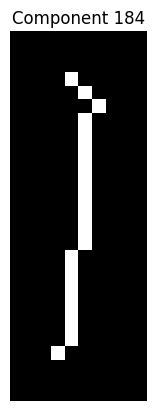

Component 184, length: 22.07 pixels, 
           length: 72.83 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 15,
           diag neighbors: 5"
        


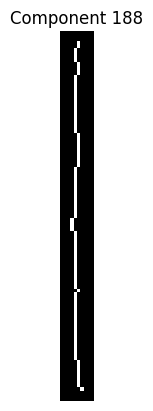

Component 188, length: 106.56 pixels, 
           length: 351.64 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 91,
           diag neighbors: 11"
        


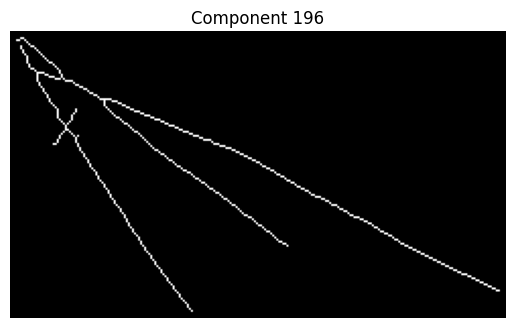

Component 196, length: 618.36 pixels, 
           length: 2040.60 microns, 
           endpoints: 0, 
           degrees: [2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2

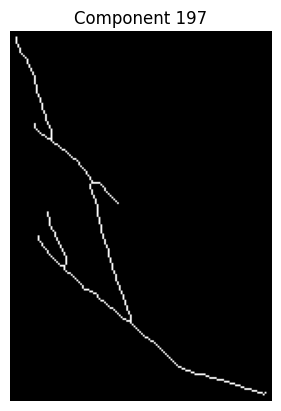

Component 197, length: 421.24 pixels, 
           length: 1390.11 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2

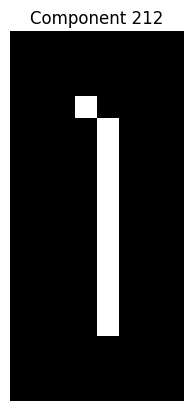

Component 212, length: 10.41 pixels, 
           length: 34.37 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 9,
           diag neighbors: 1"
        


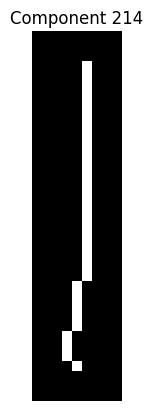

Component 214, length: 31.24 pixels, 
           length: 103.10 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 27,
           diag neighbors: 3"
        


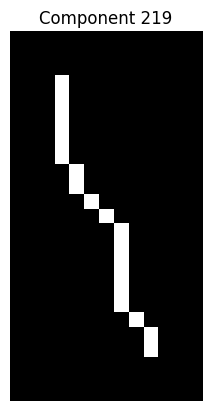

Component 219, length: 20.49 pixels, 
           length: 67.60 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 12,
           diag neighbors: 6"
        


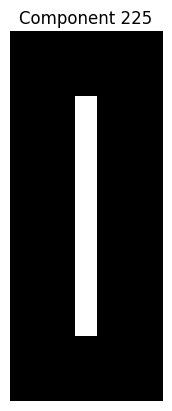

Component 225, length: 10.00 pixels, 
           length: 33.00 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 10,
           diag neighbors: 0"
        


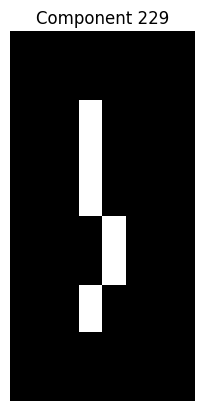

Component 229, length: 9.83 pixels, 
           length: 32.43 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 7,
           diag neighbors: 2"
        


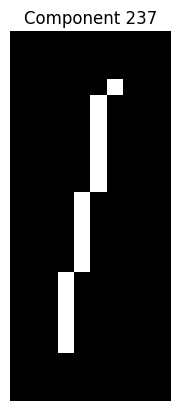

Component 237, length: 17.24 pixels, 
           length: 56.90 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 13,
           diag neighbors: 3"
        


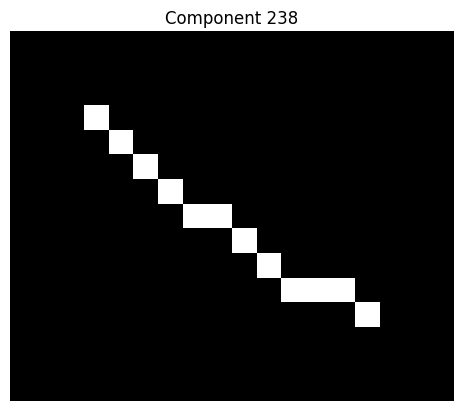

Component 238, length: 14.31 pixels, 
           length: 47.24 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 3,
           diag neighbors: 8"
        


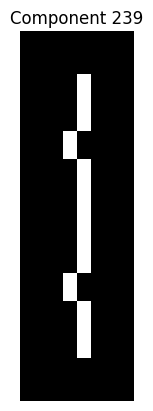

Component 239, length: 20.66 pixels, 
           length: 68.17 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 15,
           diag neighbors: 4"
        


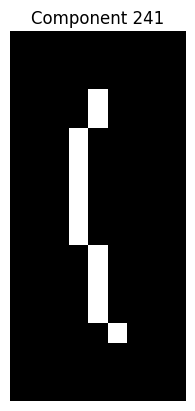

Component 241, length: 13.24 pixels, 
           length: 43.70 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 9,
           diag neighbors: 3"
        


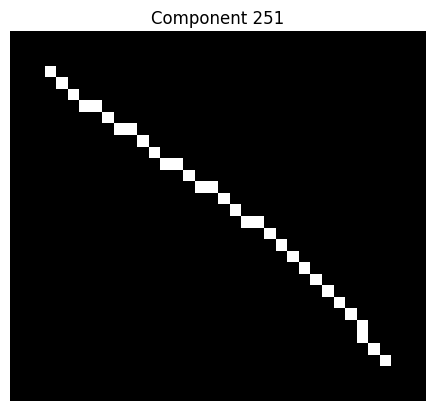

Component 251, length: 39.94 pixels, 
           length: 131.81 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 6,
           diag neighbors: 24"
        


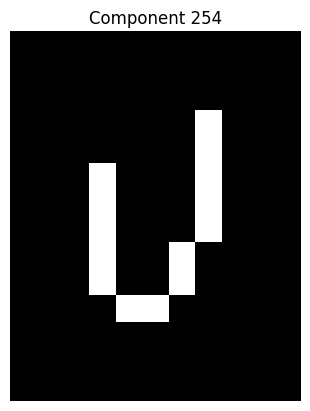

Component 254, length: 14.24 pixels, 
           length: 47.00 microns, 
           endpoints: 0, 
           degrees: [1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
           ortho neighbors: 10,
           diag neighbors: 3"
        


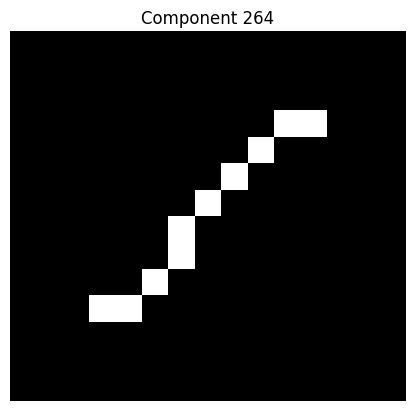

Component 264, length: 11.49 pixels, 
           length: 37.90 microns, 
           endpoints: 0, 
           degrees: [2, 1, 2, 2, 2, 2, 2, 2, 1, 2],
           ortho neighbors: 3,
           diag neighbors: 6"
        


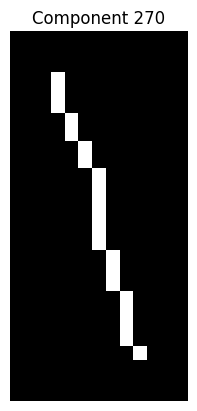

Component 270, length: 22.49 pixels, 
           length: 74.20 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 14,
           diag neighbors: 6"
        


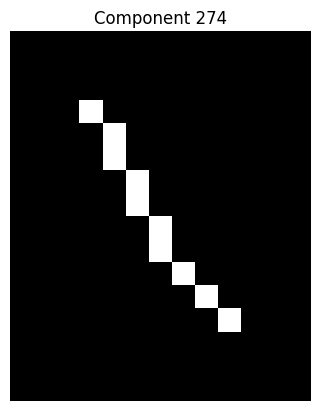

Component 274, length: 11.49 pixels, 
           length: 37.90 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 3,
           diag neighbors: 6"
        


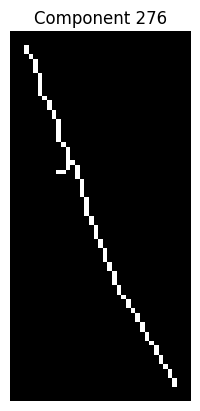

Component 276, length: 93.08 pixels, 
           length: 307.17 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 4, 3, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 45,
           diag neighbors: 34"
        


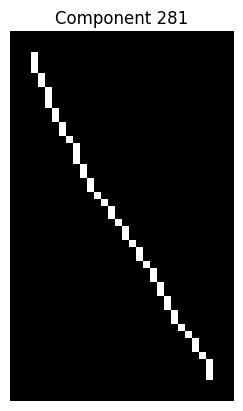

Component 281, length: 56.36 pixels, 
           length: 185.97 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 21,
           diag neighbors: 25"
        


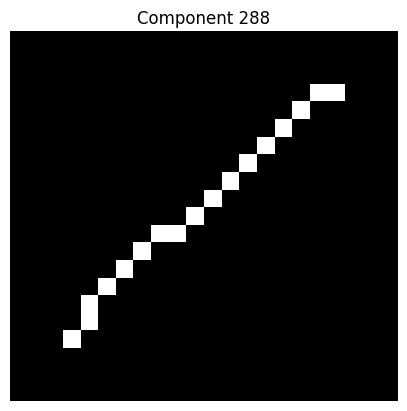

Component 288, length: 21.38 pixels, 
           length: 70.57 microns, 
           endpoints: 0, 
           degrees: [2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 3,
           diag neighbors: 13"
        


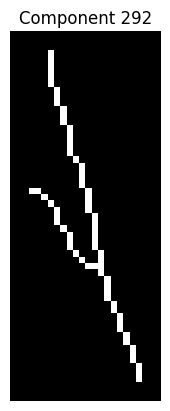

Component 292, length: 78.94 pixels, 
           length: 260.51 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 45,
           diag neighbors: 24"
        


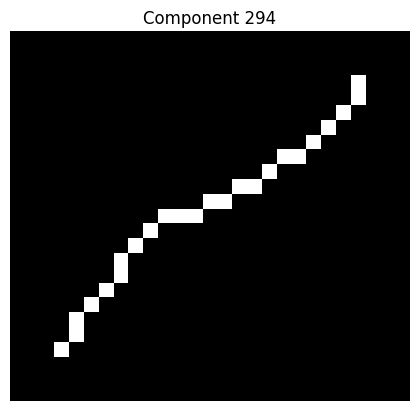

Component 294, length: 29.21 pixels, 
           length: 96.40 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 8,
           diag neighbors: 15"
        


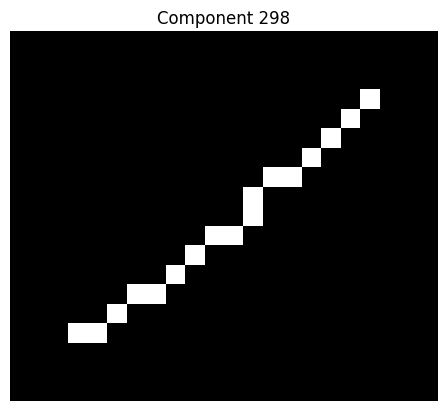

Component 298, length: 20.56 pixels, 
           length: 67.84 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2],
           ortho neighbors: 5,
           diag neighbors: 11"
        


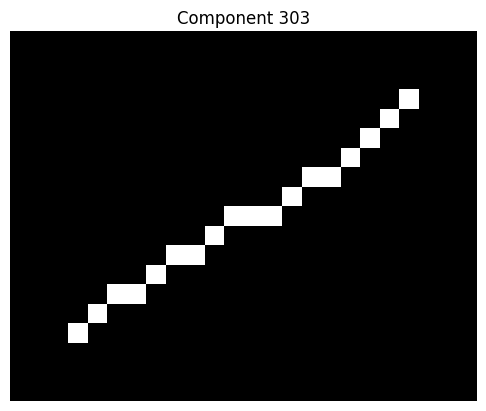

Component 303, length: 21.97 pixels, 
           length: 72.50 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 5,
           diag neighbors: 12"
        


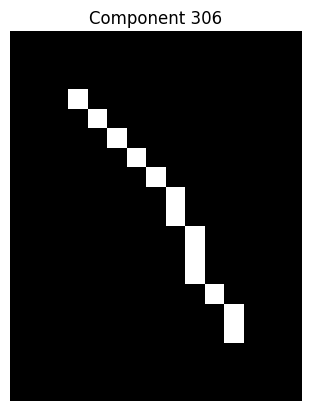

Component 306, length: 15.31 pixels, 
           length: 50.54 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 4,
           diag neighbors: 8"
        


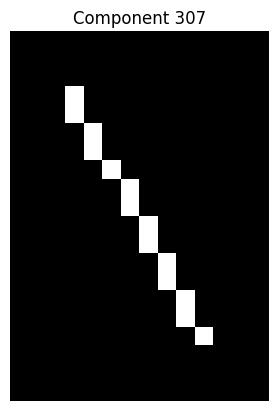

Component 307, length: 15.90 pixels, 
           length: 52.47 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 6,
           diag neighbors: 7"
        


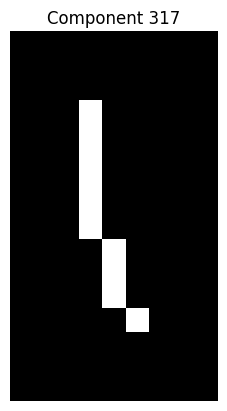

Component 317, length: 9.83 pixels, 
           length: 32.43 microns, 
           endpoints: 0, 
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 7,
           diag neighbors: 2"
        
Number of filtered components: 72


In [95]:
# Create new mask for root hairs using adaptive thresholding

better_adapt = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 8)
root_hair_mask = better_adapt.copy()
expanded_root_mask = cv2.dilate(mask_closed_contour, np.ones((10,10), np.uint8), iterations=1)
root_hair_mask[expanded_root_mask > 0] = 0
# root_hair_mask[mask_closed_contour > 0] = 0

# Skeletonize the root hair mask
skeletonized_hairs = sk.morphology.skeletonize(root_hair_mask // 255)
skeletonized_hairs = (skeletonized_hairs * 255).astype(np.uint8)

# Add main root boundary countour to skeletonized hairs to make a version with contours
skeletonized_hairs_with_contours = skeletonized_hairs.copy()
skeletonized_hairs_with_contours = cv2.drawContours(skeletonized_hairs_with_contours, contours, -1, 255, 1)


skeletonized_hairs_binary = (skeletonized_hairs > 0).astype(np.uint8)
components_masks = sk.measure.label(skeletonized_hairs_binary, connectivity=2)
num_objects = components_masks.max()
print(f"Number of connected components: {num_objects}")

filtered = 0 # for testing
microscope_conversion_factor = 3.3 # variable for user 

for i in range(0, num_objects + 1):
    one_component_mask = (components_masks == i).astype(np.uint8)

    # for testing 
    if one_component_mask.sum() == 0:
        continue
    if one_component_mask.sum() < 10:  # Filter out small components
        continue
    if one_component_mask.sum() > 500:  # Filter out large components
        continue
    
    y, x = np.where(one_component_mask > 0)
    adjustment = 3
    h , w = one_component_mask.shape
    y_min = max(0, y.min() - adjustment)
    y_max = min(h-1, y.max() + adjustment)
    x_min = max(0, x.min() - adjustment)
    x_max = min(w-1, x.max() + adjustment)

    cropped_component_mask = one_component_mask[y_min:y_max+1, x_min:x_max+1]

    # make a set of all pixels that make up the component (in tuples)
    coords = np.argwhere(cropped_component_mask > 0)
    root_hair_pixel_set = set(tuple(coordinate) for coordinate in coords)

    # make a kernel that holds the 8 neighbors of a pixel
    neighbors = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1), (1, 0), (1, 1)
    ]
    # also make kernels that hold 2 orthogonal neighbors and 2 diagonal neighbors (forward directions only)
    ortho_neighbors = [(0, 1), (1, 0)]
    diag_neighbors = [(1, 1), (1, -1)]

    list_of_degrees = []
    num_ortho_neighbors = 0
    num_diag_neighbors = 0

    # for each pixel in the component:
    for y, x in coords:
        num_neighbors = 0
        # check how many of its neighbors are also in the component by comparing 8-neighbor kernel
        for dy, dx in neighbors:
            if (y + dy, x + dx) in root_hair_pixel_set:
                num_neighbors += 1
            # if it has no neighbors, reject
            if num_neighbors == 0:
                continue
            # if it has 3 or more neighbors, reject 
            if num_neighbors >= 3:
                continue
        list_of_degrees.append(num_neighbors)
        
        # check how many orthogonal neighbors are in the component by comparing to ortho kernel
        for dy, dx in ortho_neighbors:
            if (y + dy, x + dx) in root_hair_pixel_set:
                num_ortho_neighbors += 1
        # check how many diagonal neighbors are in the component by comparing to diag kernel 
        for dy, dx in diag_neighbors:
            if (y + dy, x + dx) in root_hair_pixel_set:
                num_diag_neighbors += 1
    
    endpoints = np.sum(list_of_degrees == 1)
    branchpoints = np.sum(list_of_degrees != 2 or list_of_degrees != 1)
    middle_points = np.sum(list_of_degrees == 2)

    # calculate the length of the component using ortho and diag neighbors
    length = num_ortho_neighbors + (num_diag_neighbors * np.sqrt(2))
    length_in_microns = length * microscope_conversion_factor

    # for testing
    filtered += 1
    plt.imshow(cropped_component_mask, cmap='gray')
    plt.title(f"Component {i}")
    plt.axis('off')
    plt.show()
    print(f'''Component {i}, length: {length:.2f} pixels, 
           length: {length_in_microns:.2f} microns, 
           endpoints: {endpoints}, 
           degrees: {list_of_degrees},
           ortho neighbors: {num_ortho_neighbors},
           diag neighbors: {num_diag_neighbors}"
        ''')

# testing
print(f"Number of filtered components: {filtered}")

In [96]:
'''I think I need to consider finding alternatives to connectedComponents
It looks like it isn't able to distinguish the individual root hairs. 
Other options Google has recommended:
- cv2.findContours
- cv2.simpleBlobDetector
- skimage.measure.label
- skimage.measure.regionprops
- skan (specifically for skeletons)'''

"I think I need to consider finding alternatives to connectedComponents\nIt looks like it isn't able to distinguish the individual root hairs. \nOther options Google has recommended:\n- cv2.findContours\n- cv2.simpleBlobDetector\n- skimage.measure.label\n- skimage.measure.regionprops\n- skan (specifically for skeletons)"

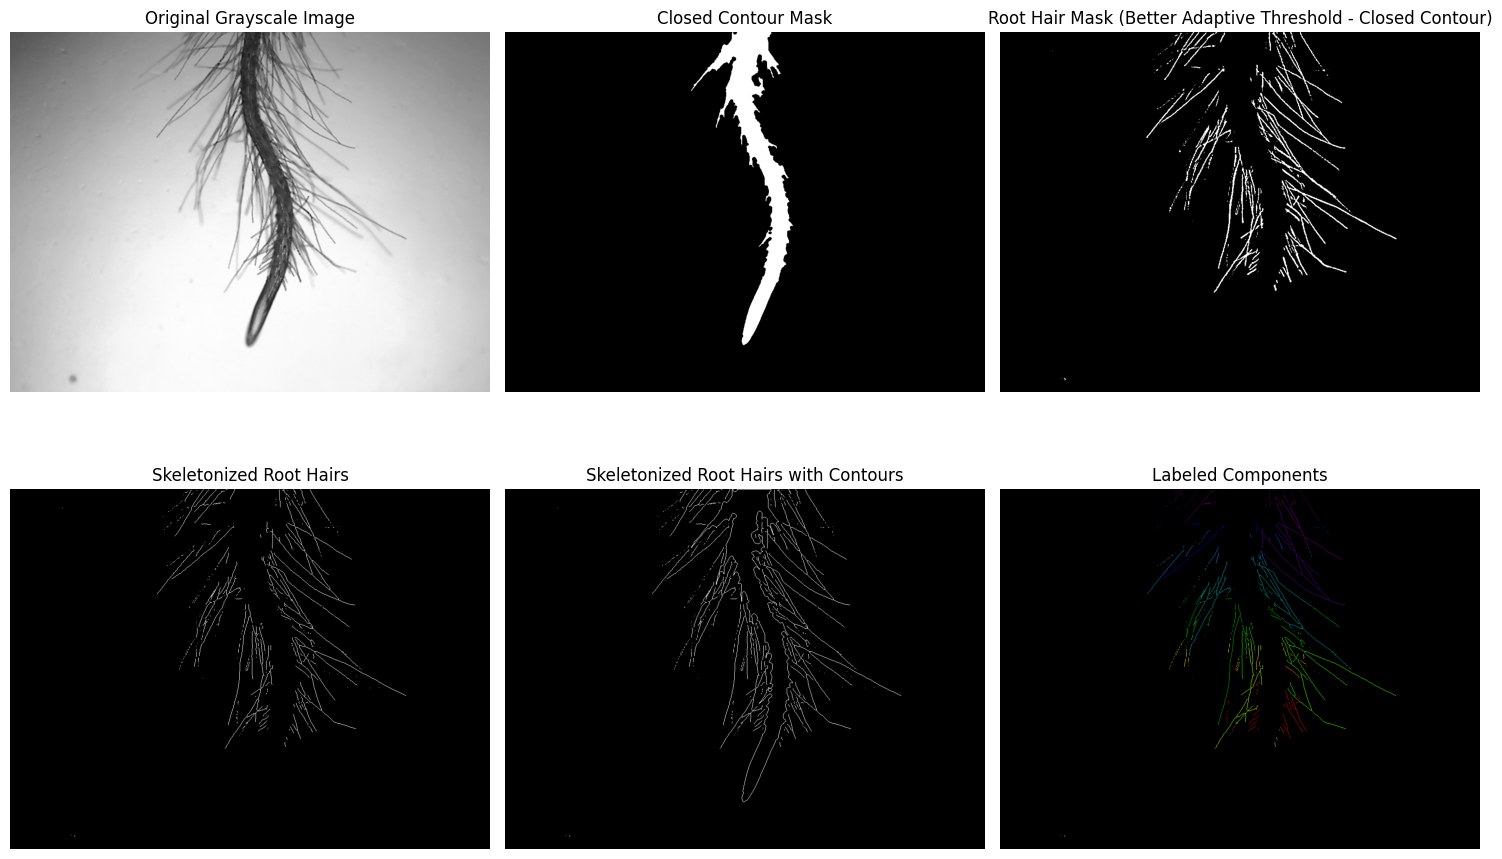

In [97]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(image_gray, cmap='gray')
ax[0, 0].set_title('Original Grayscale Image')
ax[0, 0].axis('off')
ax[0, 1].imshow(mask_closed_contour, cmap='gray')
ax[0, 1].set_title('Closed Contour Mask')
ax[0, 1].axis('off')
ax[0, 2].imshow(root_hair_mask, cmap='gray')
ax[0, 2].set_title('Root Hair Mask (Better Adaptive Threshold - Closed Contour)')
ax[0, 2].axis('off')
ax[1, 0].imshow(skeletonized_hairs, cmap='gray')
ax[1, 0].set_title('Skeletonized Root Hairs')
ax[1, 0].axis('off')
ax[1, 1].imshow(skeletonized_hairs_with_contours, cmap='gray')
ax[1, 1].set_title('Skeletonized Root Hairs with Contours')
ax[1, 1].axis('off')
ax[1, 2].imshow(components_masks, cmap='nipy_spectral')
ax[1, 2].set_title('Labeled Components')
ax[1, 2].axis('off')
plt.tight_layout()
plt.show()